<a href="https://colab.research.google.com/github/Edwinshajan2006/data-science-/blob/main/TEST_SAMPLE_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df=pd.read_csv('/content/train.csv')


In [21]:
df.shape



(593994, 13)

In [22]:
df.head()


,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


In [23]:
df

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
593989,593989,23004.26,0.152,703,20958.37,10.92,Female,Single,High School,Employed,Business,C3,1.0
593990,593990,35289.43,0.105,559,3257.24,14.62,Male,Single,Bachelor's,Employed,Debt consolidation,F5,1.0
593991,593991,47112.64,0.072,675,929.27,14.13,Female,Married,Bachelor's,Employed,Debt consolidation,C1,1.0
593992,593992,76748.44,0.067,740,16290.40,9.87,Male,Single,Bachelor's,Employed,Debt consolidation,B2,1.0


In [24]:
df.isnull().sum()

,0
id,0
annual_income,0
debt_to_income_ratio,0
credit_score,0
loan_amount,0
interest_rate,0
gender,0
marital_status,0
education_level,0
employment_status,0


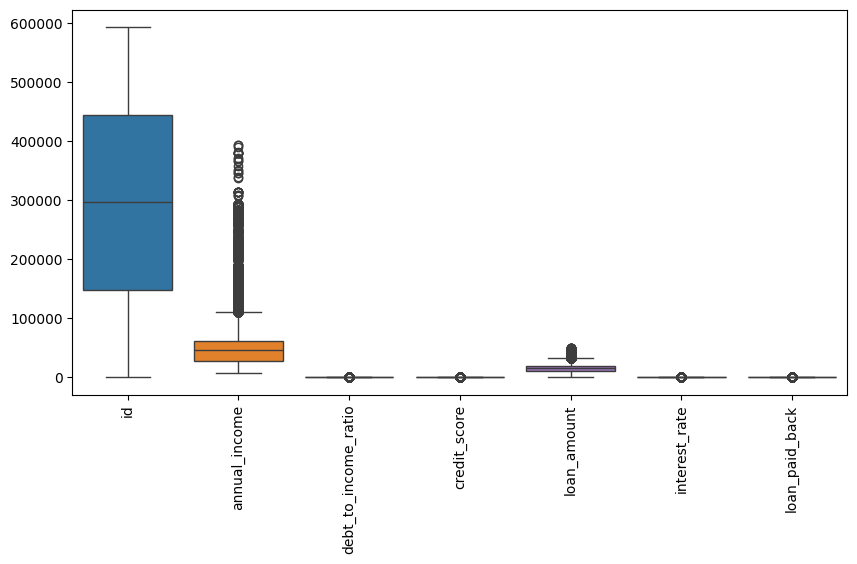

In [25]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

In [26]:
Q1=df['annual_income'].quantile(0.25)
Q3=df['annual_income'].quantile(0.75)

IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR

In [27]:
outliers=df[(df['annual_income']<lower_bound) | (df['annual_income']>upper_bound)]
outliers.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
22,22,135416.72,0.160,661,12404.14,13.30,Male,Single,High School,Unemployed,Debt consolidation,D1,0.0
42,42,139563.11,0.221,635,11890.21,13.93,Male,Single,Bachelor's,Employed,Business,D2,1.0
76,76,155380.35,0.049,714,18213.43,11.79,Female,Single,Bachelor's,Employed,Car,C1,1.0
80,80,154021.77,0.107,649,12606.58,14.32,Female,Single,High School,Employed,Business,D1,1.0
123,123,143439.01,0.351,713,8579.47,13.29,Male,Single,Other,Employed,Debt consolidation,C3,0.0


In [29]:
df=df[(df['annual_income']>lower_bound)&(df['annual_income']<upper_bound)]
df.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


In [30]:
df.shape

(578077, 13)

In [31]:
X=df.drop('loan_paid_back',axis=1)
y=df['loan_paid_back']

In [32]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [33]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
numerical_cols = X_train.select_dtypes(include=np.number).columns
categorical_cols = X_train.select_dtypes(include='object').columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

In [34]:
from sklearn.tree import DecisionTreeClassifier
tree=DecisionTreeClassifier(max_depth=4,min_samples_split=10,min_samples_leaf=5,random_state=42)
tree.fit(X_train_scaled,y_train)

DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, min_samples_split=10,
                       random_state=42)

In [35]:
prediction=tree.predict(X_test_scaled)
from sklearn.metrics import accuracy_score
accuracy_score(y_test,prediction)

0.9001781760309991

In [36]:
y_train_pred=tree.predict(X_train_scaled)
print('training accuracy', accuracy_score(y_train,y_train_pred))
y_test_pred=tree.predict(X_test_scaled)
print('testing accuracy', accuracy_score(y_test,y_test_pred))

training accuracy 0.9002899703975038
testing accuracy 0.9001781760309991


In [37]:
from sklearn.metrics import confusion_matrix,classification_report
print(classification_report(y_test,prediction))
confusion_matrix(y_test,prediction)



              precision    recall  f1-score   support

         0.0       0.93      0.55      0.69     23187
         1.0       0.90      0.99      0.94     92429

    accuracy                           0.90    115616
   macro avg       0.91      0.77      0.81    115616
weighted avg       0.90      0.90      0.89    115616



array([[12666, 10521],
       [ 1020, 91409]])

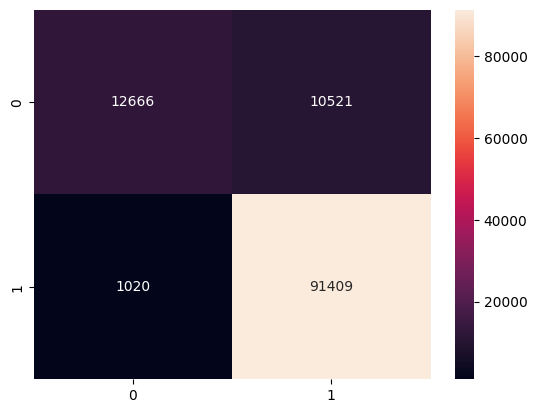

In [38]:
cm=confusion_matrix(y_test,prediction)
sns.heatmap(cm,annot=True,fmt='d')
plt.show()